# MIC 1175Ah 0.25P 循环老化对标

固定流程：原始 Excel -> 标准 lifecycle .dat -> 25°C / 45°C 0.25P 分块寿命仿真 -> 实测均值曲线对标。


## 1. 环境与导入

只在这里初始化路径、reload 和项目 API。


In [ ]:
# Environment setup and imports
%load_ext autoreload
%autoreload 2

import importlib
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import pybamm

SEARCH_ROOT = Path.cwd().resolve()
PROJECT_ROOT = None
for candidate in (SEARCH_ROOT, *SEARCH_ROOT.parents):
    if (candidate / "src" / "easy_imports.py").exists() and (candidate / "pyproject.toml").exists():
        PROJECT_ROOT = candidate
        break
    if (candidate / "BatteryProject" / "src" / "easy_imports.py").exists():
        PROJECT_ROOT = candidate / "BatteryProject"
        break
if PROJECT_ROOT is None:
    raise FileNotFoundError(f"Cannot locate BatteryProject root from {SEARCH_ROOT}")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.easy_imports import (
    BatteryPlotter,
    DEFAULT_PULSE_LIFECYCLE_MODEL_OPTIONS,
    configure_notebook_environment,
    export_cycle_life_dat,
    get_discharge_capacity,
    load_lifecycle_dat,
    p_rate_to_power_w,
    run_pulse_lifecycle_scenarios,
)

PROJECT_ROOT, WORKSPACE_ROOT, PARAMS_ROOT = configure_notebook_environment(
    project_root=PROJECT_ROOT,
)

plt.style.use("science")
plt.rcParams["font.family"] = "Calibri, Microsoft YaHei"


## 2. 用户配置与数据路径

集中配置原始 Excel、processed dat、输出目录和寿命仿真参数。


In [ ]:
# User configuration
PARAMS_MODULE_NAME = "paramsMIC"
OUTPUT_NAME = "MIC_1175Ah_0p25P_cycle_life_compare"
RAW_EXCEL_PATH = WORKSPACE_ROOT / "data_raw" / "MIC_1175Ah" / "Hithium_TI_∞Cell 1175Ah_循环寿命 Cycle Life_20260523_V1.1(45℃循环预测曲线调整).xlsx"
PROCESSED_DIR = WORKSPACE_ROOT / "data_processed" / "MIC_1175Ah" / "cycle_life_0p25P_20260523"
PROCESSED_DAT_PATH = PROCESSED_DIR / "MIC_1175Ah_0p25P_cycle_life.dat"
OUTPUT_DIR = PROJECT_ROOT / "output" / OUTPUT_NAME
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

RATE_P = 0.25
TEMPERATURE_RANGE = [298.15, 318.15]
NOMINAL_CAPACITY_AH = 1175.0
NOMINAL_VOLTAGE_V = 3.2
CHARGE_CUTOFF_V = 3.65
DISCHARGE_CUTOFF_V = 2.50
REST_MINUTES = 10.0
PERIOD_MINUTES = 0.5

ACCELERATION_FACTOR = 50
TOTAL_REAL_CYCLES = 1400
USE_BLOCK_ACCELERATION =False
# BLOCK_ACCELERATION_CONFIG = {"cycles_per_block": 4}
RETURN_SOLUTIONS = False
SHOW_PROGRESS = True

VAR_PTS = {"x_n": 5, "x_s": 5, "x_p": 5, "r_n": 20, "r_p": 20}
RESULT_EXCEL_PATH = OUTPUT_DIR / f"{OUTPUT_NAME}_cycle_metrics.xlsx"

params_module = importlib.import_module(PARAMS_MODULE_NAME)
importlib.reload(params_module)
get_hithium_params = params_module.get_hithium_params

param_check = get_hithium_params(1, 298.15)
assert "Nominal cell capacity [A.h]" in param_check
print(f"Using parameter module: {PARAMS_MODULE_NAME}")
print(f"Nominal capacity: {param_check['Nominal cell capacity [A.h]']} Ah")
print(f"0.25P power: {p_rate_to_power_w(RATE_P, NOMINAL_CAPACITY_AH, NOMINAL_VOLTAGE_V):.1f} W")
print(f"Output folder: {OUTPUT_DIR}")


## 3. 实验数据预处理

把原始 Excel 转为标准 lifecycle dat，并加载 BOL-normalized 均值曲线。


In [ ]:
# Prepare experiment dat and load BOL-normalized mean curves
cycle_life_df = export_cycle_life_dat(
    RAW_EXCEL_PATH,
    PROCESSED_DAT_PATH,
    sheet_name="0.25P",
    nominal_capacity_ah=NOMINAL_CAPACITY_AH,
    nominal_energy_wh=NOMINAL_CAPACITY_AH * NOMINAL_VOLTAGE_V,
    rate_p=RATE_P,
)
exp_data = load_lifecycle_dat(
    PROCESSED_DAT_PATH,
    curve_type="mean",
    retention_col="capacity_retention_bol",
    drop_pre_bol=True,
)

display(cycle_life_df.groupby(["curve_type", "temperature_c"]).size().rename("rows").reset_index())
for item in exp_data:
    print(f"{item['label']}: {item['cycle'].size} points, final retention={item['retention'][-1]:.4f}")


,curve_type,temperature_c,rows
0,mean,25.0,1227
1,mean,45.0,1364
2,measured_cell,25.0,2454
3,measured_cell,45.0,2724
4,prediction,25.0,54
5,prediction,45.0,31


## 4. 25°C / 45°C 分块寿命仿真

复用 run_pulse_lifecycle_scenarios，按温度分别运行并收集结果。


In [ ]:
# Simulation loop: 25°C / 45°C 0.25P CP-DP lifecycle
runtime_config = {
    "total_cycles": TOTAL_REAL_CYCLES,
    "aging_t_factor": ACCELERATION_FACTOR,
    "conditioning_t_factor": 1,
    "showprogress": SHOW_PROGRESS,
    "use_block_acceleration": USE_BLOCK_ACCELERATION,
}
if USE_BLOCK_ACCELERATION:
    runtime_config.update(BLOCK_ACCELERATION_CONFIG)

base_scenarios = [
    {
        "name": "base_0p25P",
        "display_name": "0.25P CP-DP",
        "enabled": True,
        "pulse_p_rate": None,
        "base_p_rate": RATE_P,
    }
]

sim_results = {}
summary_rows = []
for temperature in TEMPERATURE_RANGE:
    label = f"{temperature - 273.15:.0f}°C {RATE_P:g}P"
    print(f"\nRunning simulation for {label}")
    batch = run_pulse_lifecycle_scenarios(
        base_scenarios,
        runtime_config,
        model_options=DEFAULT_PULSE_LIFECYCLE_MODEL_OPTIONS,
        var_pts=VAR_PTS,
        nominal_capacity_ah=NOMINAL_CAPACITY_AH,
        temperature_k=temperature,
        get_hithium_params=get_hithium_params,
        get_discharge_capacity_func=get_discharge_capacity,
        base_p_rate=RATE_P,
        nominal_voltage_v=NOMINAL_VOLTAGE_V,
        charge_cutoff_v=CHARGE_CUTOFF_V,
        discharge_cutoff_v=DISCHARGE_CUTOFF_V,
        rest_minutes=REST_MINUTES,
        period_minutes=PERIOD_MINUTES,
        return_solutions=RETURN_SOLUTIONS,
    )
    bundle = batch["results"]["base_0p25P"]
    main_df = bundle["main_df"].copy()
    main_df["label"] = label
    main_df["temperature_k"] = temperature
    sim_results[label] = {"batch": batch, "bundle": bundle, "main_df": main_df}
    final = main_df.iloc[-1].to_dict() if not main_df.empty else {}
    final["label"] = label
    summary_rows.append(final)

summary_df = pd.DataFrame(summary_rows)
display(summary_df[["label", "real_cycle", "discharge_capacity_ah", "capacity_retention"]])


,label,real_cycle,discharge_capacity_ah,capacity_retention
0,25°C 0.25P,1449.964286,1104.141394,0.908317
1,45°C 0.25P,1449.964286,1074.315716,0.878528


## 5. 表格整理与导出

汇总仿真、实验、误差和配置，统一写入 output 目录。


In [ ]:
# Export simulation and comparison tables
sim_metrics_raw_df = pd.concat(
    [item["main_df"] for item in sim_results.values()],
    ignore_index=True,
) if sim_results else pd.DataFrame()

exp_metrics_frames = []
for exp in exp_data:
    exp_df = pd.DataFrame(
        {
            "source": "experiment",
            "label": exp["label"],
            "cycle": exp["cycle"],
            "discharge_capacity_ah": exp["discharge_capacity"],
            "capacity_retention": exp["retention"],
            "curve_type": exp.get("curve_type", ""),
        }
    )
    temperature = exp.get("temperature")
    if temperature is not None and len(temperature) == len(exp_df):
        exp_df["temperature_c"] = temperature
    exp_df["capacity_retention_pct"] = exp_df["capacity_retention"] * 100.0
    exp_metrics_frames.append(exp_df)
exp_metrics_df = pd.concat(exp_metrics_frames, ignore_index=True) if exp_metrics_frames else pd.DataFrame()

sim_metrics_df = sim_metrics_raw_df.copy()
if not sim_metrics_df.empty:
    sim_metrics_df["source"] = "simulation"
    if "temperature_k" in sim_metrics_df.columns:
        sim_metrics_df["temperature_c"] = sim_metrics_df["temperature_k"] - 273.15
    if "real_cycle" in sim_metrics_df.columns:
        sim_metrics_df["cycle"] = sim_metrics_df["real_cycle"]
    sim_metrics_df["capacity_retention_pct"] = sim_metrics_df["capacity_retention"] * 100.0
    preferred_cols = [
        "source",
        "label",
        "temperature_c",
        "cycle",
        "real_cycle",
        "sim_cycle",
        "discharge_capacity_ah",
        "capacity_retention",
        "capacity_retention_pct",
    ]
    sim_metrics_df = sim_metrics_df[
        [col for col in preferred_cols if col in sim_metrics_df.columns]
        + [col for col in sim_metrics_df.columns if col not in preferred_cols]
    ]

sim_plot_df = pd.DataFrame()
if not sim_metrics_df.empty:
    sim_plot_df = sim_metrics_df.dropna(
        subset=["cycle", "discharge_capacity_ah", "capacity_retention"]
    ).copy()
    keep_cols = [
        "source",
        "label",
        "cycle",
        "discharge_capacity_ah",
        "capacity_retention",
        "capacity_retention_pct",
        "temperature_c",
    ]
    sim_plot_df = sim_plot_df[[col for col in keep_cols if col in sim_plot_df.columns]]

comparison_long_df = pd.concat(
    [frame for frame in [exp_metrics_df, sim_plot_df] if not frame.empty],
    ignore_index=True,
) if (not exp_metrics_df.empty or not sim_plot_df.empty) else pd.DataFrame()

summary_export_df = summary_df.copy() if "summary_df" in globals() else pd.DataFrame()
if not summary_export_df.empty and "capacity_retention" in summary_export_df.columns:
    summary_export_df["capacity_retention_pct"] = summary_export_df["capacity_retention"] * 100.0

config_df = pd.DataFrame(
    [
        {"parameter": "PARAMS_MODULE_NAME", "value": PARAMS_MODULE_NAME},
        {"parameter": "RATE_P", "value": RATE_P},
        {"parameter": "NOMINAL_CAPACITY_AH", "value": NOMINAL_CAPACITY_AH},
        {"parameter": "NOMINAL_VOLTAGE_V", "value": NOMINAL_VOLTAGE_V},
        {"parameter": "CHARGE_CUTOFF_V", "value": CHARGE_CUTOFF_V},
        {"parameter": "DISCHARGE_CUTOFF_V", "value": DISCHARGE_CUTOFF_V},
        {"parameter": "REST_MINUTES", "value": REST_MINUTES},
        {"parameter": "PERIOD_MINUTES", "value": PERIOD_MINUTES},
        {"parameter": "ACCELERATION_FACTOR", "value": ACCELERATION_FACTOR},
        {"parameter": "TOTAL_REAL_CYCLES", "value": TOTAL_REAL_CYCLES},
        {"parameter": "USE_BLOCK_ACCELERATION", "value": USE_BLOCK_ACCELERATION},
        {"parameter": "CYCLES_PER_BLOCK", "value": runtime_config.get("cycles_per_block", "")},
        {"parameter": "VAR_PTS", "value": str(VAR_PTS)},
        {"parameter": "RAW_EXCEL_PATH", "value": str(RAW_EXCEL_PATH)},
        {"parameter": "PROCESSED_DAT_PATH", "value": str(PROCESSED_DAT_PATH)},
    ]
)

with pd.ExcelWriter(RESULT_EXCEL_PATH) as writer:
    config_df.to_excel(writer, sheet_name="config", index=False)
    summary_export_df.to_excel(writer, sheet_name="sim_summary", index=False)
    sim_metrics_df.to_excel(writer, sheet_name="sim_metrics", index=False)
    sim_metrics_raw_df.to_excel(writer, sheet_name="sim_metrics_raw", index=False)
    exp_metrics_df.to_excel(writer, sheet_name="exp_mean", index=False)
    comparison_long_df.to_excel(writer, sheet_name="comparison_long", index=False)
    if "cycle_life_df" in globals() and not cycle_life_df.empty:
        cycle_life_df.to_excel(writer, sheet_name="processed_dat", index=False)

print(f"Wrote {RESULT_EXCEL_PATH}")
display(comparison_long_df.head())


,source,label,cycle,discharge_capacity_ah,capacity_retention,curve_type,temperature_c,capacity_retention_pct
0,experiment,25°C 0.25P,0.0,1214.48385,1.000000,mean,25.0,100.000000
1,experiment,25°C 0.25P,1.0,1214.31480,0.999861,mean,25.0,99.986081
2,experiment,25°C 0.25P,2.0,1213.95270,0.999563,mean,25.0,99.956266
3,experiment,25°C 0.25P,3.0,1213.54150,0.999224,mean,25.0,99.922408
4,experiment,25°C 0.25P,4.0,1213.07775,0.998842,mean,25.0,99.884223


## 6. 容量/SOH 对标图

用 BatteryPlotter 叠加仿真和实测均值。


(<Figure size 4200x1500 with 2 Axes>,
 (<Axes: title={'center': 'Discharge Capacity'}, xlabel='Cycle Number', ylabel='Capacity (Ah)'>,
  <Axes: title={'center': 'Capacity Retention'}, xlabel='Cycle Number', ylabel='Retention (%)'>))

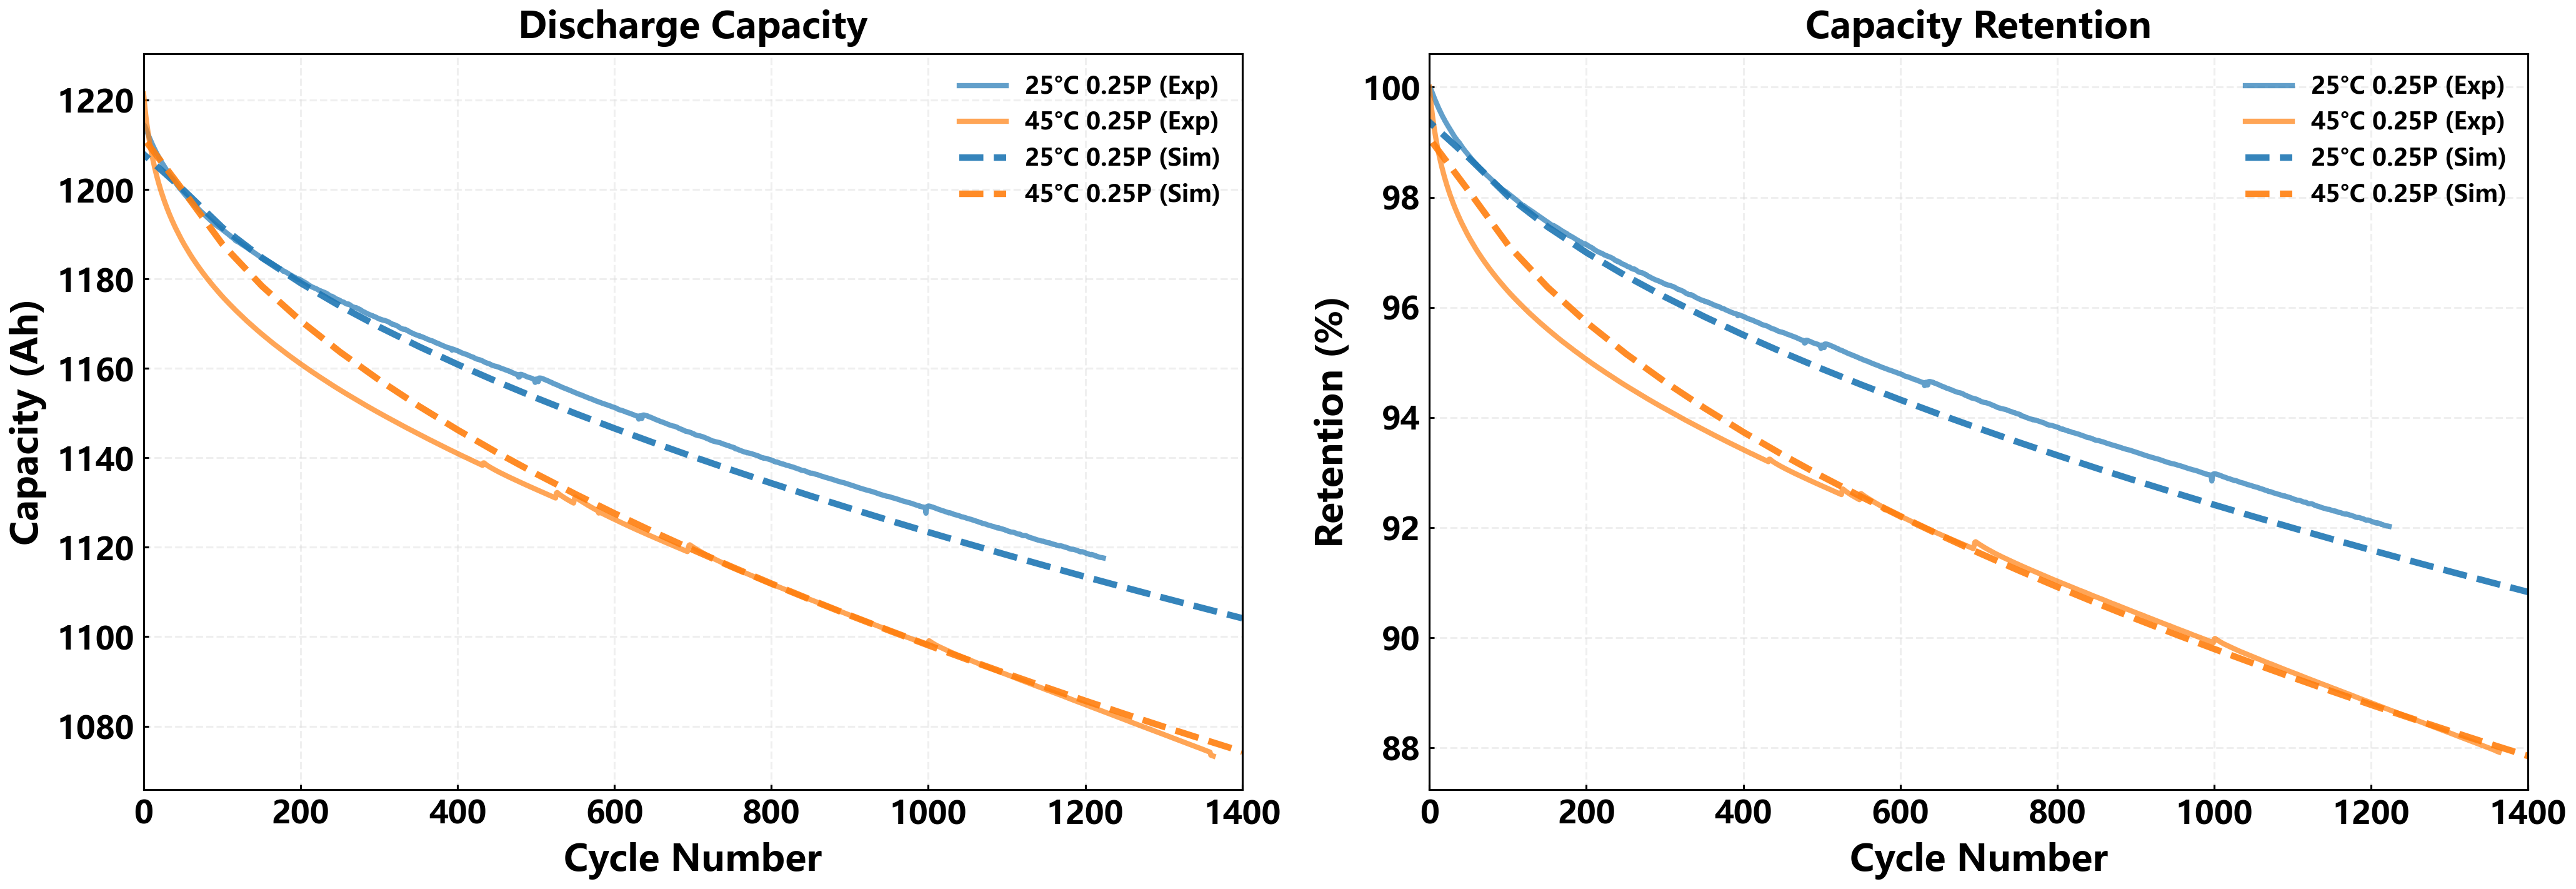

In [ ]:
# Capacity / SOH comparison against processed experiment data
capacity_plotter = BatteryPlotter()
for exp in exp_data:
    capacity_plotter.add_exp_data(
        exp["label"],
        exp["cycle"],
        exp["discharge_capacity"],
        exp["retention"],
    )

for label, item in sim_results.items():
    df = item["main_df"].dropna(subset=["real_cycle", "discharge_capacity_ah", "capacity_retention"])
    capacity_plotter.add_sim_data(
        label,
        np.array(df["real_cycle"].to_numpy(dtype=float))-50,
        df["discharge_capacity_ah"].to_numpy(dtype=float),
        df["capacity_retention"].to_numpy(dtype=float),
    )

capacity_plotter.plot(
    target_exp="all",
    target_sim="all",
    title_left="Discharge Capacity",
    ylabel_left="Capacity (Ah)",
    title_right="Capacity Retention",
    ylabel_right="Retention (%)",
    xlim=(0, TOTAL_REAL_CYCLES),
)


## 7. 单体离散性检查

可选查看每个实测 cell 的散点和线形分布。


In [ ]:
# Optional: cell-level experiment scatter/lines for dispersion check
cell_exp_data = load_lifecycle_dat(
    PROCESSED_DAT_PATH,
    curve_type="measured_cell",
    retention_col="capacity_retention_bol",
    drop_pre_bol=True,
)
cell_plotter = BatteryPlotter()
for exp in cell_exp_data:
    cell_plotter.add_exp_data(exp["label"], exp["cycle"], exp["discharge_capacity"], exp["retention"])
cell_plotter.plot(
    target_exp="all",
    title_left="Cell-Level Discharge Capacity",
    ylabel_left="Capacity (Ah)",
    title_right="Cell-Level Capacity Retention",
    ylabel_right="Retention (%)",
    xlim=(0, TOTAL_REAL_CYCLES),
)


## 8. 复用点记录

- src.lifecycle_exp.export_cycle_life_dat / load_lifecycle_dat: 固定 Excel -> lifecycle dat -> exp_data_list 的入口，Notebook 不再手写 Excel 分块解析。
- src.simulation.p_rate_to_power_w: 固定 P-rate -> W 换算，Notebook 不再写 rate * capacity * voltage。
- src.simulation.DEFAULT_PULSE_LIFECYCLE_MODEL_OPTIONS: 复用已有老化模型选项，避免 notebook 内重复维护 DFN options。
- src.simulation.run_pulse_lifecycle_scenarios: 使用分块续算承载长期寿命仿真，避免把 conditioning/aging loop 散落在 notebook 中。
- src.plotting.BatteryPlotter: 统一容量和保持率对标图，不再在 notebook 中重复封装绘图格式。
